In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm
from math import comb, atan2
from itertools import product

In [2]:
# ------------------------------------------------------------- Hamiltonian
def Hv(P, X, mu):
    """mu x (number of PAIRS of particles occupying the same state)."""
    diag = np.zeros(X**P, dtype=complex)
    for idx, conf in enumerate(product(range(X), repeat=P)): # product outputs combinations of (0,0,0) (0,0,1) etc in same ordering as tensor prod
        pairs = sum(1 for i in range(P) for j in range(i+1, P)
                    if conf[i] == conf[j])
        diag[idx] = mu*pairs
    return diag

def Hh0(P,X,a):
    h0base = a/2*np.array([[1, -1],[-1, 1]], dtype=complex)
    IX = np.eye(X,dtype=complex)
    h0full = np.zeros((X**P,X**P),dtype=complex)
    for p in range(P): 
        # want to sum over the p 1body hamiltonians 
        elements = [h0base if i==p else IX for i in range(P)]

        # build the kronecker producted form for the pth 1body hamiltonian
        h0 = elements[0]
        for element in elements[1:]:
            h0 = np.kron(h0,element)
        h0full += h0
    return h0full


def fullHam(P,X,a,mu):
    h0 = Hh0(P,X,a)
    v = np.diag(Hv(P,X,mu))
    return h0 + v


# ------------------------------------------------------------- kernels

def _factors(psi):
    """  [psi[:,0,:], ..., psi[:,P-1,:]], each (N,X)."""
    return [psi[:, k, :] for k in range(P)]


def _build(factors):
    """Tensor-product the P factors into the (N, X**P) many-body kets."""
    out = factors[0]
    for k in range(1, P):
        out = np.einsum('ai,aj->aij', out, factors[k]).reshape(N, -1)
    return out


def overlap(psi, k):
    """ overlap[a,b] = <phi_{a k} | phi_{b k}>, 
    Shape (N,N). 
    Overlap matrix of kth single-particle orbitals between alpha and beta slater """
    return np.einsum('ai,bi->ab', psi[:, k, :].conj(), psi[:, k, :])


def overlap_products(ov):
    """
    ov is [overlap(psi, k) for k in range(P)], overlap(psi,k) is (N,N)
    ov becomes (P,N,N) after the np.stack below

    Vectorised replacement for N_, N_p, N_kp.

    Returns
        Nfull  (N,N)      prod over all k
        Np     (P,N,N)    prod over k != p
        Nkp    (P,P,N,N)  prod over i != k,p   (zero on the k == p diagonal)
    """
    S = np.stack(ov)     # (P,N,N)
    Nfull = np.prod(S, axis=0) # (N,N) elementwise multiplication of the overlaps

    Np = np.empty((P, N, N), dtype=complex)
    for p in range(P):
        Np[p] = np.prod(np.delete(S, p, axis=0), axis=0) if P > 1 else 1.0

    Nkp = np.zeros((P, P, N, N), dtype=complex)
    for k in range(P):
        for p in range(P):
            if k == p:
                continue
            rest = np.delete(S, [min(k, p), max(k, p)], axis=0)  # (P-2,N,N)
            # ^ deletes the whole index row of k and p from S (ordering the smaller index first so min and max, not actually necessary)
            Nkp[k, p] = np.prod(rest, axis=0) if rest.shape[0] else 1.0 
            # ^ (N,N)
            # element wise multiplication of the P-2 overlap matrices. 
            # else 1 so that when have 2 particles and remove 2, dont get zero
    return Nfull, Np, Nkp # (N,N) (P,N,N) (P,P,N,N) ie the overlap matrix element for each alpha,beta


def H_kernel(psi):
    """H[gamma,beta] = <Phi^gamma| Ham |Phi^beta>, shape (N,N)."""
    s = _build(_factors(psi)) # (N, X**P) slaters 
    return s.conj() @ Ham @ s.T


def H_p_kernel(psi):
    """
    H_p[gamma,beta,p,xp,yp] = <phi_g1 .. x_p .. phi_gP| Ham |phi_b1 .. y_p .. phi_bP>

    Slot p carries the basis state x_p (bra) / y_p (ket) instead of an
    orbital.  Unlike the notebook version this is correct for p = 0.
    """
    e = np.eye(X, dtype=complex)
    out = np.zeros((N, N, P, X, X), dtype=complex)
    for p in range(P):
        for xp in range(X):
            fb = _factors(psi) # all the orbital states 
            fb[p] = np.broadcast_to(e[xp], (N, X)).copy() # replace p slot with xp state
            bra = _build(fb).conj() @ Ham
            for yp in range(X):
                fk = _factors(psi)
                fk[p] = np.broadcast_to(e[yp], (N, X)).copy()
                out[:, :, p, xp, yp] = bra @ _build(fk).T
    return out

# ------------------------------------------------- the linear system

def build_linear_system(psi, f):
    """
    Assemble A y' = b, with y' = [d_f (N), d_psi (N*P*X)], following the
    two boxed equations of the PDF.

        row block 1 (N rows)   :  sum_b (d_f_b) N_gb
                                  = -sum_b f_b [ sum_k sum_xk N^k_gb
                                     phi*_{g k xk} (d_t phi_{b k xk}) + i H_gb ]

        row block 2 (N*P*X)    :  sum_b f_b N^p_gb (d_t phi_{b p xp})
                                  = -sum_b f_b sum_{k!=p} sum_xk N^{kp}_gb
                                       phi_{b p xp} phi*_{g k xk}(d_t phi_{b k xk})
                                    -sum_b (d_t f_b) phi_{b p xp} N^p_gb
                                    -sum_b i f_b sum_yp phi_{b p yp} H^p_gb(xp,yp)
    """
    ov = [overlap(psi, k) for k in range(P)]
    Nfull, Np, Nkp = overlap_products(ov) # (N,N) (P,N,N) (P,P,N,N)

    # --- LHS blocks
    I_f = Nfull      # (N,N)

    I_psi = np.zeros((N, P, X, N, P, X), dtype=complex)
    idx_p, idx_x = np.meshgrid(np.arange(P), np.arange(X), indexing='ij') 
    # ^ grid (P,X) with every index pair of p and xp. arange(P) is 0,1,...P-1
    for g in range(N):
        for b in range(N):
            I_psi[g, idx_p, idx_x, b, idx_p, idx_x] = f[b]*Np[idx_p, g, b]
    I_psi = I_psi.reshape(NY, NY) # NY is N*P*X

    # --- coupling blocks (moved to the LHS as -M)
    M_fpsi = -np.einsum('b,kgb,gkx->gbkx', f, Np, psi.conj()).reshape(N, NY) 
    # ^ reshape f x psi, take in shape psi, spit out shape f

    M_psif = -np.einsum('bpx,pgb->gpxb', psi, Np).reshape(NY, N) # reshape psi x f

    M_psipsi = -np.einsum('b,kpgb,bpx,gky->gpxbky',
                          f, Nkp, psi, psi.conj()).reshape(NY, NY) # reshape psi x psi

    # --- inhomogeneous parts, ie b in Ay' = b
    df_base = -1j*np.einsum('a,ba->b', f, H_kernel(psi))

    psiH = np.einsum('bpy,gbpxy->gbpx', psi, H_p_kernel(psi))
    dpsi_base = (-1j*np.einsum('b,gbpx->gpx', f, psiH)).ravel()

    A = np.block([[I_f,     -M_fpsi],
                  [-M_psif,  I_psi - M_psipsi]])
    b = np.concatenate((df_base, dpsi_base))
    return A, b


def gauge_rows(psi):
    """
    MCTXH constraint rows enforcing <phi_{gamma k}| d_t phi_{gamma k}> = 0,
    which holds the norm of every orbital fixed for all time.
    """
    G = np.zeros((N*P, N + NY), dtype=complex)
    row = 0
    for g in range(N):
        for k in range(P):
            blk = np.zeros((N, P, X), dtype=complex)
            blk[g, k, :] = psi[g, k, :].conj()
            G[row, N:] = blk.ravel() # everything after N ie not the d_f parts
            row += 1
    return G


def minnorm_solve(A, b, rcond=1e-10):
    """
    Minimum-norm solution of a consistent, rank-deficient system, via a
    rank-truncated SVD.  
    A x = b   ->   x = A^+ b,      A^+ = V Sigma^+ U^dagger 
    and Sigma^+ is just diag of 1/singular vals 
    
    Returns (x, rank, residual). residual should be zero 
    """
    U, s, Vh = np.linalg.svd(A, full_matrices=False)
    keep = s > rcond*s[0] # ie only want singular values above the tolerance

    # now the minimum norm solution to the linear system 
    x = Vh[keep].conj().T @ ((U[:, keep].conj().T @ b)/s[keep])
    return x, int(keep.sum()), np.linalg.norm(A @ x - b) 

# --------------------------------------------------- the RHS

def rhs(t, y, rcond=1e-10, gauge=True):
    f = y[:N]
    psi = y[N:].reshape(N, P, X)
    A, b = build_linear_system(psi, f)
    if gauge:
        A = np.vstack([A, gauge_rows(psi)])
        b = np.concatenate([b, np.zeros(N*P, dtype=complex)])
    x, _, _ = minnorm_solve(A, b, rcond)
    return x


In [3]:
# ------------------------------------------------------- observables

def full_state(f, psi):
    """|Psi> as a (X**P,) vector."""
    return f @ _build(_factors(psi))


def unpack(sol):
    f = sol.y[:N, :]
    psi = sol.y[N:, :].reshape(N, P, X, -1)
    return f, psi


def observables(sol):
    """Exact <Psi|Psi> and <Psi|H|Psi> including all cross terms."""
    f, psi = unpack(sol)
    nt = f.shape[1]
    norm = np.empty(nt, dtype=complex)
    energy = np.empty(nt, dtype=complex)
    for i in range(nt):
        Psi = full_state(f[:, i], psi[..., i])
        norm[i] = Psi.conj() @ Psi
        energy[i] = Psi.conj() @ Ham @ Psi
    return norm, energy # norm.real, energy.real


def Nleft(sol):
    f, psi = unpack(sol)
    nt = f.shape[1]

    left = np.array([conf.count(0) for conf in product(range(X), repeat=P)],
                    dtype=complex)
    # ^ count(0) counts how many times a 0 appears in conf, conf is (i,j,k) 
    # where ijk are 0 or 1 in same ordering as the tensor products
    NL = np.diag(left)

    Nleft_t = np.empty(nt, dtype=complex)
    for t in range(nt):
        Psi = full_state(f[:, t], psi[..., t])
        Nleft_t[t] = Psi.conj() @ NL @ Psi
    return Nleft_t


def Nleft_exact(y0,t_list):
    left = np.array([conf.count(0) for conf in product(range(X), repeat=P)],
                    dtype=complex)
    # ^ count(0) counts how many times a 0 appears in conf, conf is (i,j,k) 
    # where ijk are 0 or 1 in same ordering as the tensor products
    NL = np.diag(left)

    Nleft_t = np.empty(len(t_list), dtype=complex)
    for i, t in enumerate(t_list):
        Psi = exact_state(y0,t)
        Nleft_t[i] = Psi.conj() @ NL @ Psi
    return Nleft_t


def exact_state(y0, t):
    """Exact solution of i dPsi/dt = H Psi from the same initial state."""
    f0 = y0[:N]
    psi0 = y0[N:].reshape(N, P, X)
    Psi0 = full_state(f0, psi0)
    return expm(-1j*Ham*t) @ Psi0


In [4]:
# ------------------------------------------------- initial condition

def make_y0(HFmin,allL,f0=(1.0, 0.0)):
    f = np.array(f0, dtype=complex)
    f = f/np.linalg.norm(f)

    psi = np.zeros((N, P, X), dtype=complex)
    
    ''' STARTING THE 2 SLATERS ORTHOGONAL '''
    assert N==2
    if HFmin:
        th = atan2(-1/mu,-np.sqrt(mu**2-1)/mu) # get same sin(th) even if remove - from second input (like the other solution would give)
        phi = 0
        L = np.sqrt( (1+np.sin(th))/2 )
        R = np.sqrt( (1-np.sin(th))/2 )*np.exp(1j*phi)
        # for n in range(N):
        for p in range(P):
            psi[0,p,:] = [L,R]
            psi[0,p,:] /= np.linalg.norm(psi[0,p,:])
            psi[1,p,:] = [R,-L]
            psi[1,p,:] /= np.linalg.norm(psi[1,p,:])
    if allL:
        # for n in range(N):
        for p in range(P):
            psi[0,p,:] = [1.0,0.0]
            psi[1,p,:] = [0.0,-1.0]

    if allL == HFmin:
        raise AttributeError('pick a starting state queen')

    return np.concatenate((f, psi.ravel()))


def integrate(y0, t_list, rcond=1e-10, gauge=True, **kw): # **kw says to collect any leftover keyword arguments
    opts = dict(method="DOP853", rtol=1e-10, atol=1e-12) # dictionary of 3 settings to use, the default
    opts.update(kw) # keyword argument, overwrites any that you want to be updated
    return solve_ivp(lambda t, y: rhs(t, y, rcond, gauge),
                     (t_list[0], t_list[-1]), y0, t_eval=t_list, **opts)


In [5]:
N = 2 # number of slaters
P = 4 # number of particles
X = 2 # number of single-particle states

a = 1.0
mu = -2.0

Ham = fullHam(P,X,a,mu)
assert Ham.shape == (X**P, X**P)  

NY = N*P*X  # length of the flattened psi block

In [10]:
# set up the integration 

# make_y0(HFmin,allL,f0=(1.0, 0.0))
f0 = (0.9, 0.1)
f0 /= np.linalg.norm(f0)
y0 = make_y0(False,True,f0)

# --- one-off structural report at t = 0
A, b = build_linear_system(y0[N:].reshape(N, P, X), y0[:N])
s = np.linalg.svd(A, compute_uv=False)
x, rank, res = minnorm_solve(A, b)
print("A = I_all - M_all at t=0")
print("  singular values :", np.array2string(s, precision=2))
print(f"  rank {rank}/{A.shape[0]}   nullity {A.shape[0]-rank}"
        f"   cond {s[0]/s[-1]:.2e}")
print(f"  least-squares residual ||Ax-b|| = {res:.2e}"
        f"   (||b|| = {np.linalg.norm(b):.2e})")

Ag = np.vstack([A, gauge_rows(y0[N:].reshape(N, P, X))])
bg = np.concatenate([b, np.zeros(N*P, dtype=complex)])
_, rank_g, res_g = minnorm_solve(Ag, bg)
print(f"  with gauge rows: rank {rank_g}/{Ag.shape[1]}"
        f"   residual {res_g:.2e}")

A = I_all - M_all at t=0
  singular values : [4.98e+00 2.29e+00 9.94e-01 9.94e-01 9.94e-01 9.94e-01 1.10e-01 1.10e-01
 1.10e-01 1.10e-01 2.00e-16 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 0.00e+00]
  rank 10/18   nullity 8   cond inf
  least-squares residual ||Ax-b|| = 7.96e-15   (||b|| = 2.24e+01)
  with gauge rows: rank 18/18   residual 4.77e-15


C:\Users\annas\AppData\Local\Temp\ipykernel_37912\1070040186.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  f"   cond {s[0]/s[-1]:.2e}")


In [14]:
# --- integrate
t_list = np.linspace(0.0, 100.0, 801)

# integrate(y0, t_list, rcond=1e-10, gauge=True, **kw)
sol = integrate(y0, t_list)
print(f"\nintegration: success={sol.success}  nfev (no. times deriv function was called)={sol.nfev}"
        f"  reached t={sol.t[-1]:.3f}  '{sol.message}'")
if not sol.success:
    raise RuntimeError(
        f"Integration failed: {sol.message}"
    )



integration: success=True  nfev (no. times deriv function was called)=38213  reached t=100.000  'The solver successfully reached the end of the integration interval.'


In [15]:
print(sol.t[-2:], t_list[-1])   # how far did it get before failing?
print(sol.status, sol.message)

print(sol.y.shape)

# extract the solution
f, psi = unpack(sol)

[ 99.875 100.   ] 100.0
0 The solver successfully reached the end of the integration interval.
(18, 801)


max norm.imag: 0.0  max energy.imag: 3.552713678800501e-15

  norm   drift  : 5.979e-09
  energy drift  : 6.045e-08
  max |Psi_TDVP - Psi_exact| : 6.359e-01
  max orbital-norm drift from 1 : 1.217e-10


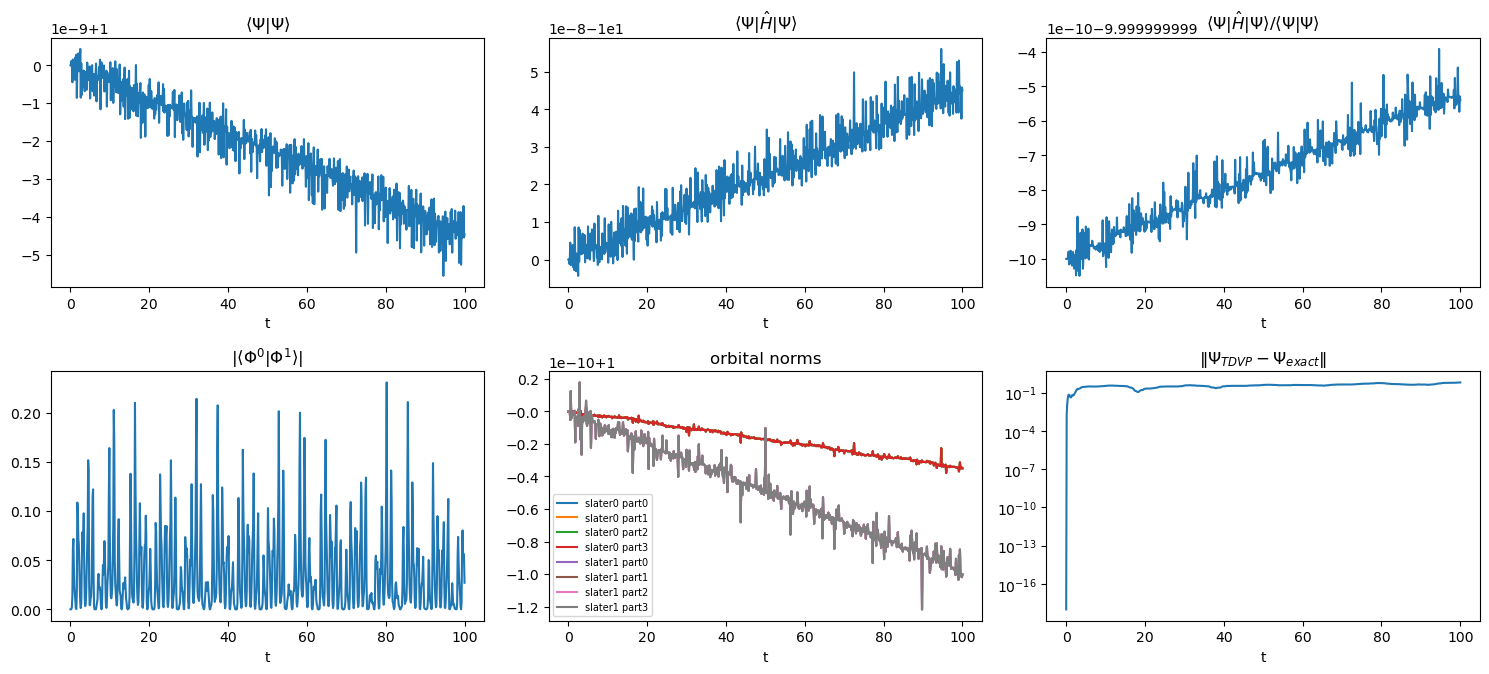

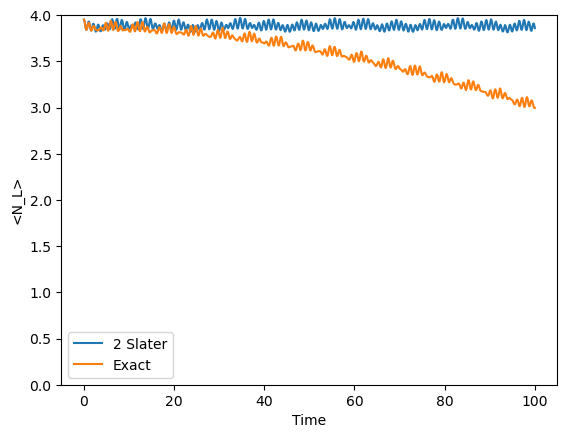

In [16]:

# Psiexact = np.array([exact_state(y0, t) for t in sol.t],dtype=complex)
norm, energy = observables(sol)
print('max norm.imag:',np.max(norm.imag),' max energy.imag:',np.max(energy.imag))
norm, energy = norm.real, energy.real
Nleft_t = Nleft(sol)
Nleft_t_exact = Nleft_exact(y0,sol.t)

# --- exact benchmark.  For N=P=X=2 the ansatz spans the whole Hilbert
#     space, so TDVP must reproduce the exact dynamics identically.
err = np.array([
    np.linalg.norm(full_state(f[:, i], psi[..., i]) - exact_state(y0, t))
    for i, t in enumerate(sol.t)])

print(f"\n  norm   drift  : {np.ptp(norm):.3e}") # peak-to-peak 
print(f"  energy drift  : {np.ptp(energy):.3e}")
print(f"  max |Psi_TDVP - Psi_exact| : {err.max():.3e}")

orbnorm = np.abs(psi)**2
orbnorm = orbnorm.sum(axis=2)         # (N,P,nt)
print(f"  max orbital-norm drift from 1 : {np.abs(orbnorm-1).max():.3e}")

slatov = np.prod(np.einsum('pxt,pxt->pt',
                            psi[0].conj(), psi[1]), axis=0) # pick which slater

# --- plots
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
ax[0, 0].plot(sol.t, norm)
ax[0, 0].set_title(r'$\langle\Psi|\Psi\rangle$')
ax[0, 1].plot(sol.t, energy)
ax[0, 1].set_title(r'$\langle\Psi|\hat H|\Psi\rangle$')
ax[0, 2].plot(sol.t, energy/norm)
ax[0, 2].set_title(r'$\langle\Psi|\hat H|\Psi\rangle/\langle\Psi|\Psi\rangle$')
ax[1, 0].plot(sol.t, np.abs(slatov))
ax[1, 0].set_title(r'$|\langle\Phi^0|\Phi^1\rangle|$')
for g in range(N):
    for k in range(P):
        ax[1, 1].plot(sol.t, orbnorm[g, k], label=f'slater{g} part{k}')
ax[1, 1].set_title('orbital norms')
ax[1, 1].legend(fontsize=7)
ax[1, 2].semilogy(sol.t, np.maximum(err, 1e-18))
ax[1, 2].set_title(r'$\|\Psi_{TDVP}-\Psi_{exact}\|$')
for a_ in ax.ravel():
    a_.set_xlabel('t')
fig.tight_layout()
# fig.savefig('tdvp_diagnostics.png', dpi=120)
# print("\nsaved tdvp_diagnostics.png")
plt.show()

plt.plot(sol.t,Nleft_t, label='2 Slater')
plt.plot(sol.t,Nleft_t_exact, label='Exact')
plt.xlabel('Time')
plt.ylabel('<N_L>')
plt.legend()
plt.ylim(0,P)
# plt.savefig('tdvpvsexact_Nleft.png', dpi=120)
plt.show()